#**<center>$\color{green}{\text{TUGAS 2 : KLASIFIKASI}}$</center>**

> Add blockquote



---


<p>
Universitas Terbuka adalah sebuah perguruan tinggi terbuka yang memberikan kesempatan bagi putra putri bangsa untuk menimba ilmu dan pengetahuan. UT memiliki mahasiswa dengan latar belakang yang beragam. Mahasiswanya tidak terbatas pada lulusan baru dari sma/smu/smk sederajat. Beberapa diantaranya bahkan telah/sedang bekerja. Kondisi tersebut memberikan kesulitan bagi pihak kampus dalam menerapkan strategi untuk membantu mahasiswa berhasil melewati masa kuliah dan lulus tepat waktu.
</p>

<p>
Sebagai seorang Machine Learning engineer, kamu diminta untuk membuat model yang mampu mendeteksi secara dini tigkat resiko kegagalan seorang mahasiswa. Dengan harapan jika sistem mampu memberikan informasi yang valid, maka bagian wali akademik dapat memberikan konseling yang tepat. Untuk melaksanakan tugasmu ini, kamu diberikan data yang bersumber dari dua periode penerimaan.
</p>


##Task 1
Mulailah memuat semua data yang ada ke sistem.

In [1]:
import pandas as pd
import numpy as np
 
# 1) Muat data dari kedua sumber
# ...
[df1,df2] = pd.read_csv("./Data Siswa Periode 1.csv") ,pd.read_csv("./Data Siswa Periode 2.csv")
df1.head()
df2.head()
# 2) Lihat atribut apa saja yang ada dari kedua data tersebut
# ...
print(f"{df1.info()}\n{df1.describe()} \n {df2.info()}\n{df1.describe()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   1827 non-null   int64  
 1   Status Pernikahan                    1827 non-null   object 
 2   Program Studi                        1827 non-null   object 
 3   Kelas Reguler/Malam                  1824 non-null   object 
 4   Pendidikan Terakhir                  1827 non-null   object 
 5   Nilai SMA                            1827 non-null   float64
 6   Daerah Asal                          1824 non-null   object 
 7   Pendidikan Ibu                       1827 non-null   object 
 8   Pendidikan Ayah                      1827 non-null   object 
 9   Pekerjaan Ibu                        1827 non-null   object 
 10  Pekerjaan Ayah                       1827 non-null   object 
 11  Nilai Ujian Masuk             

##Task 2
Datanya sudah termuat, fitur nya hampir semuanya sama, tetapi ada yang berbeda sehingga perlu dipetakan

In [2]:
# 1) Identifikasi fitur serupa, lakukan penamaan ulang fitur serupa
# ...
df1.columns = df1.columns.str.strip().str.lower().str.replace(' ','_')
df2.columns = df1.columns
df1.set_index("id")
df2.set_index("id")
#print(f"{df1.columns}\n{df2.columns}")
print(f"{df1.info()}\n{df2.info()}")
df1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1827 non-null   int64  
 1   status_pernikahan                    1827 non-null   object 
 2   program_studi                        1827 non-null   object 
 3   kelas_reguler/malam                  1824 non-null   object 
 4   pendidikan_terakhir                  1827 non-null   object 
 5   nilai_sma                            1827 non-null   float64
 6   daerah_asal                          1824 non-null   object 
 7   pendidikan_ibu                       1827 non-null   object 
 8   pendidikan_ayah                      1827 non-null   object 
 9   pekerjaan_ibu                        1827 non-null   object 
 10  pekerjaan_ayah                       1827 non-null   object 
 11  nilai_ujian_masuk             

,id,status_pernikahan,program_studi,kelas_reguler/malam,pendidikan_terakhir,nilai_sma,daerah_asal,pendidikan_ibu,pendidikan_ayah,pekerjaan_ibu,...,nilai_ujian_masuk,pindahan,berkebutuhan_khusus,status_pembayaran_semester_terakhir,jenis_kelamin,beasiswa,usia_saat_mendaftar,ip_semester_1,ip_semester_2,target
0,2,Belum Menikah,Teknik Industri,Reguler,SMA/Sederajat,66.55,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Lainnya,...,53.00,Ya,Tidak,Sudah,Pria,Tidak,21,2.48,2.52,Lulus Tepat Waktu
1,3,Belum Menikah,Jurnalistik,Reguler,SMA/Sederajat,63.50,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,58.25,Tidak,Tidak,Sudah,Wanita,Ya,19,2.86,2.63,Lulus Tepat Waktu
2,4,Belum Menikah,Pertanian,Reguler,SMA/Sederajat,62.50,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Wiraswasta,...,60.75,Ya,Tidak,Sudah,Pria,Tidak,18,2.20,2.07,Lulus Tidak Tepat Waktu
3,5,Belum Menikah,Teknik Mesin,Reguler,Perguruan Tinggi,75.00,Pulau Jawa,Lebih dari S1,Lebih dari S1,Pegawai Swasta,...,75.00,Tidak,Tidak,Sudah,Wanita,Tidak,20,2.60,2.40,Lulus Tidak Tepat Waktu
4,10,Belum Menikah,Perbankan,Reguler,SMA/Sederajat,65.00,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Pegawai Negri,...,64.55,Ya,Tidak,Sudah,Wanita,Tidak,18,2.61,2.72,Lulus Tepat Waktu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,32,Belum Menikah,Perpajakan,Reguler,SMA/Sederajat,66.00,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Lainnya,...,66.55,Ya,Tidak,Sudah,Pria,Tidak,19,2.40,2.10,Gagal
1823,34,Cerai,Jurnalistik,Reguler,Perguruan Tinggi,66.55,Pulau Jawa,Lebih dari S1,Lebih dari S1,Pegawai Swasta,...,58.75,Tidak,Tidak,Sudah,Wanita,Tidak,39,2.25,2.27,Lulus Tepat Waktu
1824,35,Belum Menikah,Perpajakan,Reguler,Perguruan Tinggi,75.00,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,75.00,Ya,Tidak,Sudah,Pria,Tidak,20,3.30,3.54,Gagal
1825,36,Belum Menikah,Perbankan,Reguler,SMA/Sederajat,65.00,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,58.90,Ya,Tidak,Sudah,Wanita,Ya,19,2.47,2.47,Lulus Tepat Waktu


##Task 3
Butuh penyatuan data, tapi ternyata ada kodefikasi atribut fitur yang berbeda, harus di samakan

In [3]:
from sklearn.preprocessing import OrdinalEncoder
from math import isnan
# print(f"{df1}\n{df2}")
# 1) Lakukan penyamaan kodefikasi atribut
# ...
def encode (d : pd.DataFrame,dto : list,enc : dict):
    for c in dtObject:
            le = OrdinalEncoder(
                                handle_unknown='use_encoded_value', 
                                unknown_value=-1, 
                                encoded_missing_value=-1)
            encode_array = le.fit_transform(d[[c]]).flatten()
            d[c] = pd.Series(encode_array,index=d.index).astype("Int64")
            categories = le.categories_[0]
            enc[c] = {label: idx for idx, label in enumerate(categories) 
                      if not pd.isna(label) and str(label).lower() != 'nan'}

dtObject = []
dtNum = []
Encoder = {}
for d in df1.columns:
    if df1[d].dtype in ["object"]:
        dtObject.append(d) 
    if df1[d].dtype in ["int64","float64"]: 
        dtNum.append(d)
print(f"data object : {dtObject}\ndata num :{dtNum}")
df1["jenis_kelamin"] = df1["jenis_kelamin"].replace({'Pria':'Laki-laki','Wanita':'Perempuan'})
df2["kelas_reguler/malam"] = df2["kelas_reguler/malam"].replace({'Siang':'Reguler'})

# 2) Lakukan penyatuan data
# ...

dfg = pd.concat([df1,df2],join="inner",ignore_index=True).sort_values(by='id')
dfg.set_index('id')
encode(dfg,dtObject,Encoder)

for key,val in Encoder.items():
    print(f"{key} {val}")
dfg



data object : ['status_pernikahan', 'program_studi', 'kelas_reguler/malam', 'pendidikan_terakhir', 'daerah_asal', 'pendidikan_ibu', 'pendidikan_ayah', 'pekerjaan_ibu', 'pekerjaan_ayah', 'pindahan', 'berkebutuhan_khusus', 'status_pembayaran_semester_terakhir', 'jenis_kelamin', 'beasiswa', 'target']
data num :['id', 'nilai_sma', 'nilai_ujian_masuk', 'usia_saat_mendaftar', 'ip_semester_1', 'ip_semester_2']
status_pernikahan {'Belum Menikah': 0, 'Cerai': 1, 'Menikah': 2}
program_studi {'Agronomi': 0, 'Akuntansi': 1, 'Ekonomi': 2, 'Hubungan Masyarakat': 3, 'Jurnalistik': 4, 'Keperawatan': 5, 'Manajemen': 6, 'Pariwisata': 7, 'Penyiaran': 8, 'Perbankan': 9, 'Perpajakan': 10, 'Perpustakaan': 11, 'Pertanian': 12, 'Teknik Industri': 13, 'Teknik Mesin': 14, 'Teknologi Informasi': 15}
kelas_reguler/malam {'Malam': 0, 'Reguler': 1}
pendidikan_terakhir {'Perguruan Tinggi': 0, 'SMA/Sederajat': 1}
daerah_asal {'Luar Jawa': 0, 'Pulau Jawa': 1}
pendidikan_ibu {'D3/S1/Sederajat': 0, 'Dibawah SMA/Sederaja

,id,status_pernikahan,program_studi,kelas_reguler/malam,pendidikan_terakhir,nilai_sma,daerah_asal,pendidikan_ibu,pendidikan_ayah,pekerjaan_ibu,...,nilai_ujian_masuk,pindahan,berkebutuhan_khusus,status_pembayaran_semester_terakhir,jenis_kelamin,beasiswa,usia_saat_mendaftar,ip_semester_1,ip_semester_2,target
914,1,0,0,1,1,70.00,1,2,2,2,...,70.00,1,0,1,1,0,36,2.61,2.60,1
0,2,0,13,1,1,66.55,1,1,3,0,...,53.00,1,0,1,0,0,21,2.48,2.52,1
1,3,0,4,1,1,63.50,1,3,2,2,...,58.25,0,0,1,1,1,19,2.86,2.63,1
2,4,0,12,1,1,62.50,1,1,3,3,...,60.75,1,0,1,0,0,18,2.20,2.07,2
3,5,0,14,1,0,75.00,1,2,2,2,...,75.00,0,0,1,1,0,20,2.60,2.40,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2653,3531,0,9,1,1,67.50,1,1,2,3,...,63.75,1,0,1,1,1,19,2.75,2.98,1
2654,3532,0,10,1,1,84.00,1,3,3,3,...,85.60,0,0,1,0,1,18,3.47,3.71,1
3551,3533,0,14,1,1,61.50,1,1,1,3,...,58.35,1,0,1,0,1,20,2.64,0.00,0
2655,3534,0,9,1,1,75.00,1,2,2,2,...,65.15,0,0,1,1,1,19,3.02,3.02,1


##Task 4
Sekarang kita lakukan analisis atribut untuk setiap fitur nya, mulai dengan penanganan missing/null value

In [4]:
import math
# 1)	Identifikasi dan tangani missing/null value
# ...
for i in dtNum:
    print(f"data unik numerik {i} \n{dfg.loc[dfg[i] < 0,i].unique() }")
for i in dtObject:
    print(f"data unik Object {i} \n{dfg.loc[dfg[i] < 0,i].unique() }")
   

print(f"data1 null \n{ dfg[dfg.isna().any(axis=1)]}")
dfg['usia_saat_mendaftar'] = dfg['usia_saat_mendaftar'].abs() 
dfg["kelas_reguler/malam"] = dfg['kelas_reguler/malam'].replace({-1 : 1 if "target"==1 else 0})
dfg["daerah_asal"] = dfg['daerah_asal'].replace({-1 : 0})


for key,val in Encoder.items():
    print(f"{key} {val}")
dfg

data unik numerik id 
[]
data unik numerik nilai_sma 
[]
data unik numerik nilai_ujian_masuk 
[]
data unik numerik usia_saat_mendaftar 
[-31 -25 -18 -21 -39 -23 -20]
data unik numerik ip_semester_1 
[]
data unik numerik ip_semester_2 
[]
data unik Object status_pernikahan 
<IntegerArray>
[]
Length: 0, dtype: Int64
data unik Object program_studi 
<IntegerArray>
[]
Length: 0, dtype: Int64
data unik Object kelas_reguler/malam 
<IntegerArray>
[-1]
Length: 1, dtype: Int64
data unik Object pendidikan_terakhir 
<IntegerArray>
[]
Length: 0, dtype: Int64
data unik Object daerah_asal 
<IntegerArray>
[-1]
Length: 1, dtype: Int64
data unik Object pendidikan_ibu 
<IntegerArray>
[]
Length: 0, dtype: Int64
data unik Object pendidikan_ayah 
<IntegerArray>
[]
Length: 0, dtype: Int64
data unik Object pekerjaan_ibu 
<IntegerArray>
[]
Length: 0, dtype: Int64
data unik Object pekerjaan_ayah 
<IntegerArray>
[]
Length: 0, dtype: Int64
data unik Object pindahan 
<IntegerArray>
[]
Length: 0, dtype: Int64
data 

,id,status_pernikahan,program_studi,kelas_reguler/malam,pendidikan_terakhir,nilai_sma,daerah_asal,pendidikan_ibu,pendidikan_ayah,pekerjaan_ibu,...,nilai_ujian_masuk,pindahan,berkebutuhan_khusus,status_pembayaran_semester_terakhir,jenis_kelamin,beasiswa,usia_saat_mendaftar,ip_semester_1,ip_semester_2,target
914,1,0,0,1,1,70.00,1,2,2,2,...,70.00,1,0,1,1,0,36,2.61,2.60,1
0,2,0,13,1,1,66.55,1,1,3,0,...,53.00,1,0,1,0,0,21,2.48,2.52,1
1,3,0,4,1,1,63.50,1,3,2,2,...,58.25,0,0,1,1,1,19,2.86,2.63,1
2,4,0,12,1,1,62.50,1,1,3,3,...,60.75,1,0,1,0,0,18,2.20,2.07,2
3,5,0,14,1,0,75.00,1,2,2,2,...,75.00,0,0,1,1,0,20,2.60,2.40,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2653,3531,0,9,1,1,67.50,1,1,2,3,...,63.75,1,0,1,1,1,19,2.75,2.98,1
2654,3532,0,10,1,1,84.00,1,3,3,3,...,85.60,0,0,1,0,1,18,3.47,3.71,1
3551,3533,0,14,1,1,61.50,1,1,1,3,...,58.35,1,0,1,0,1,20,2.64,0.00,0
2655,3534,0,9,1,1,75.00,1,2,2,2,...,65.15,0,0,1,1,1,19,3.02,3.02,1


##Task 5
Untuk bisa melihat bentuk dari data, kita perlu menghitung histogram dari setiap fitur. Dari situ kemudian kita bisa lanjutkan dengan penanganan outlier.

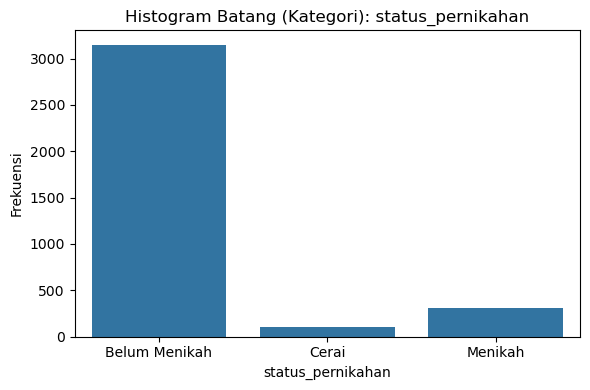

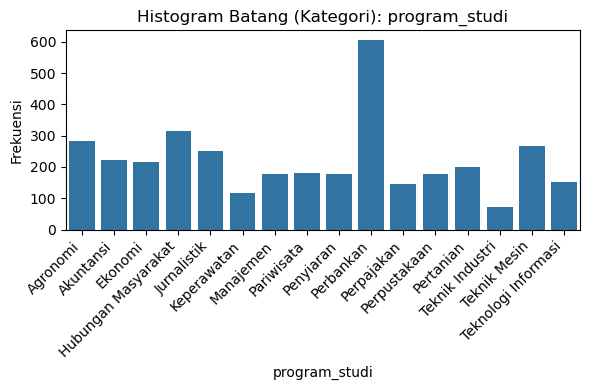

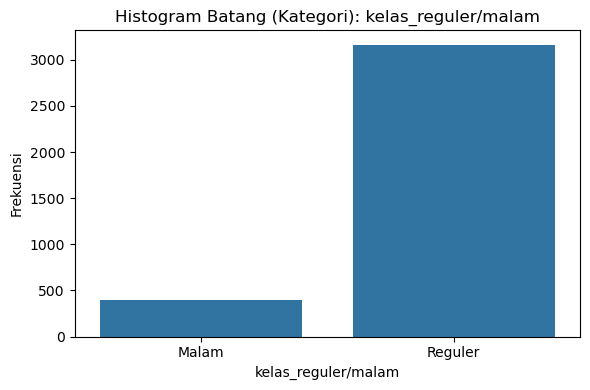

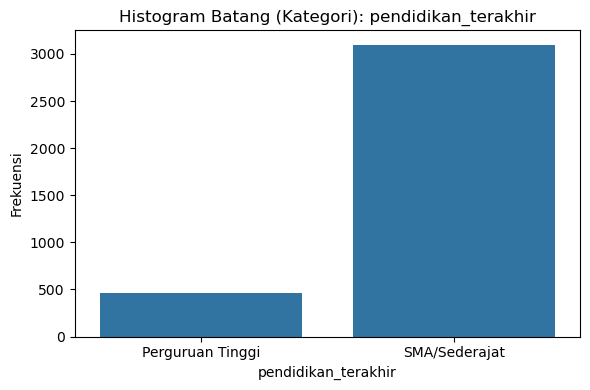

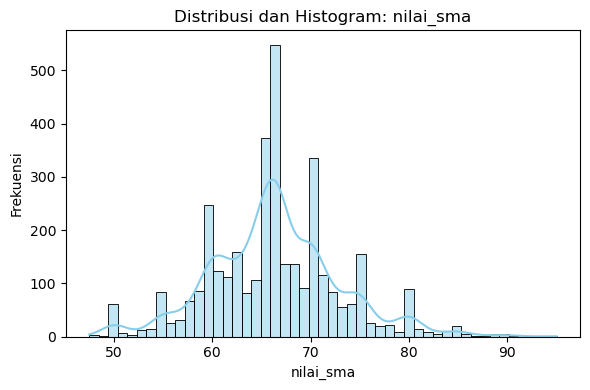

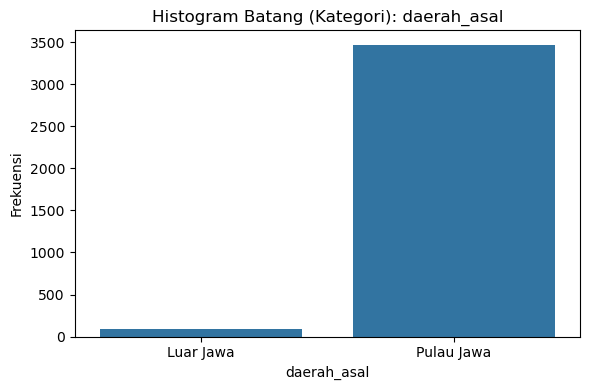

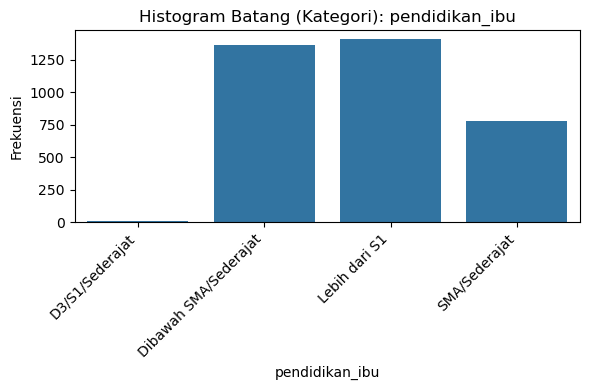

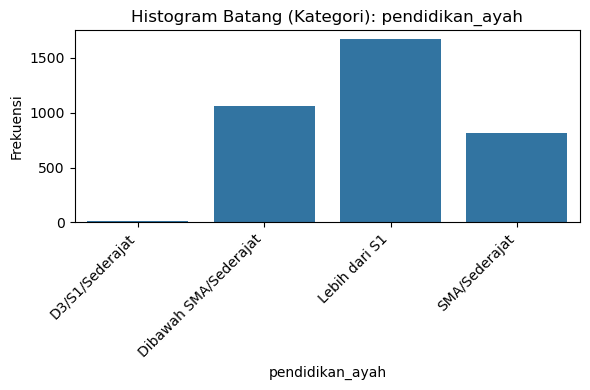

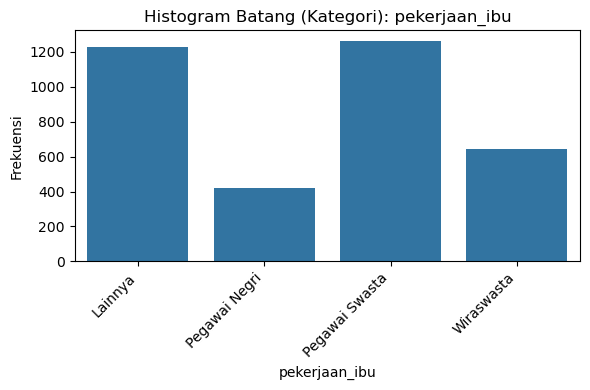

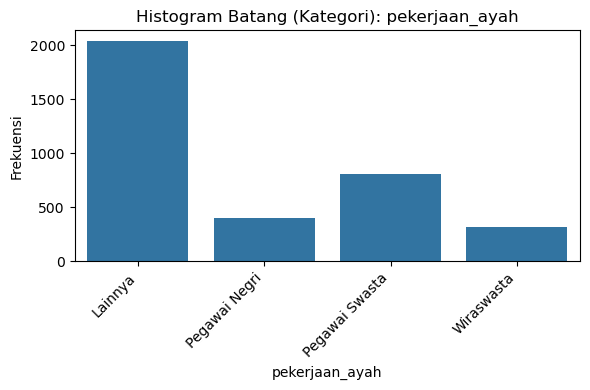

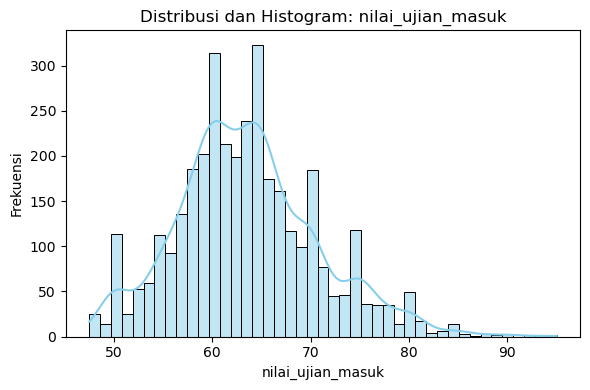

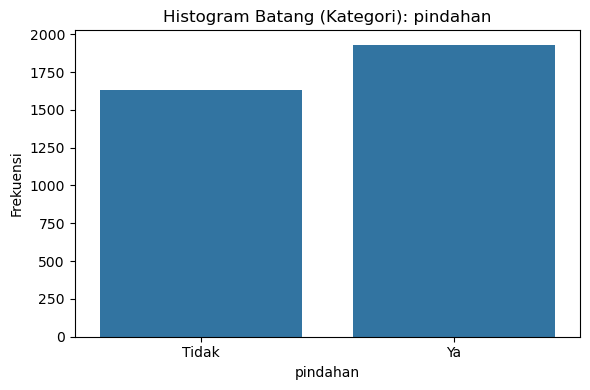

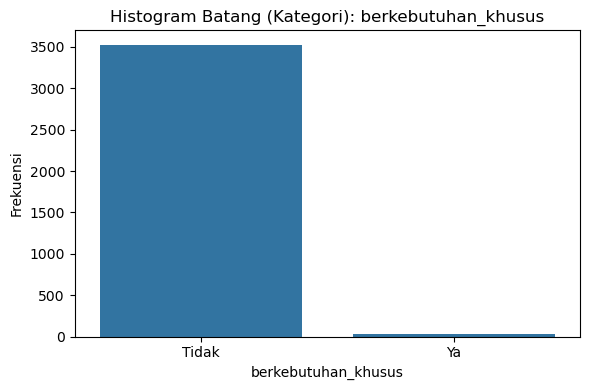

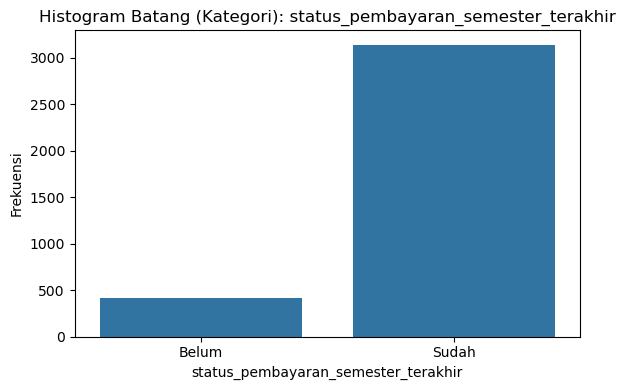

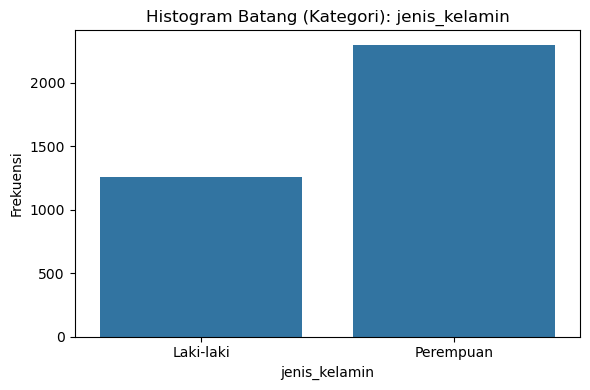

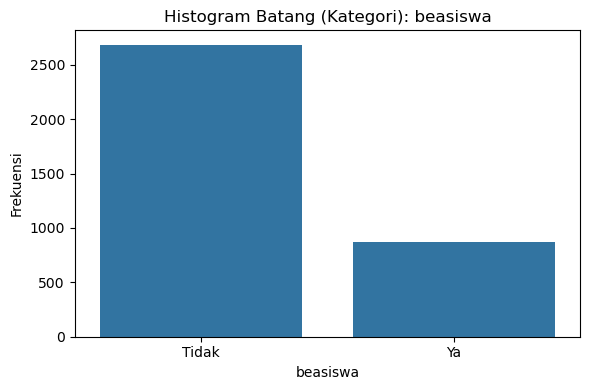

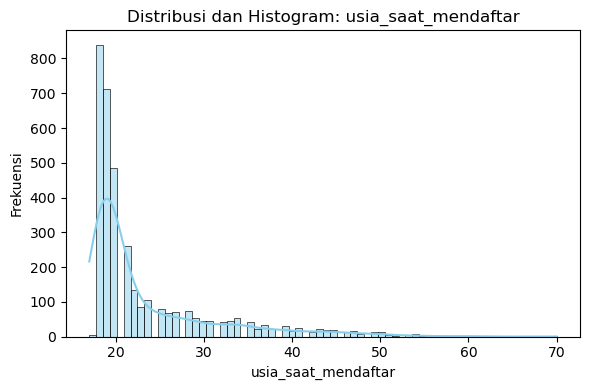

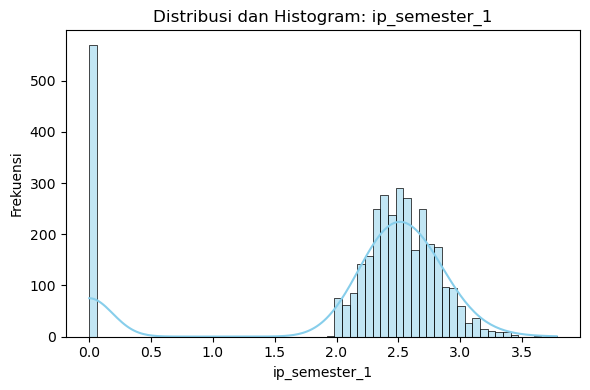

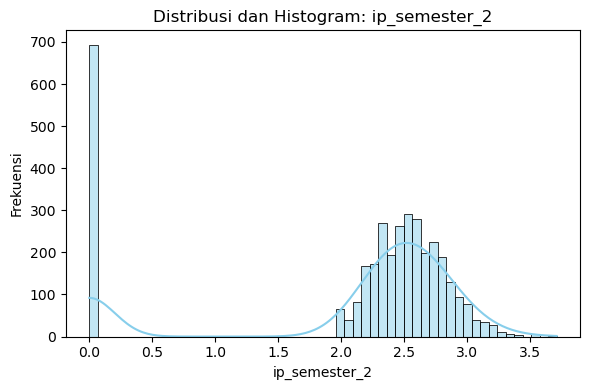

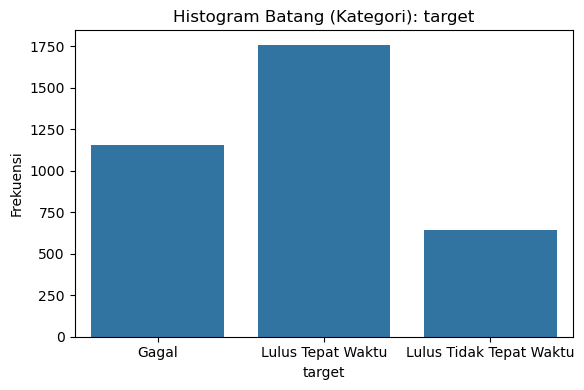

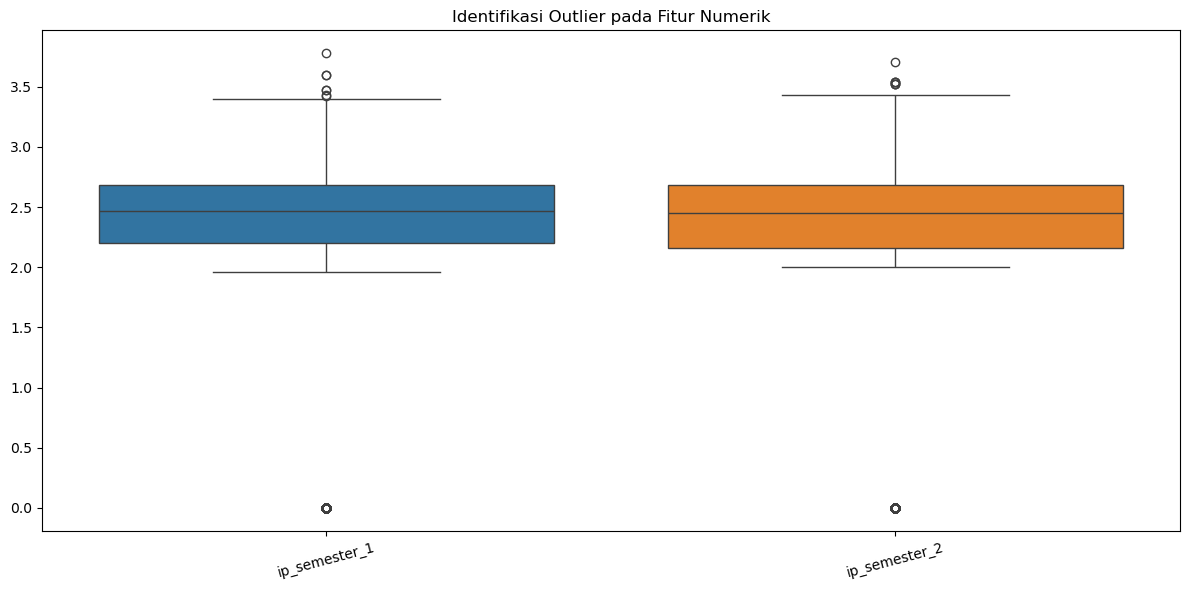

Jumlah baris sebelum menghapus outlier: 3557


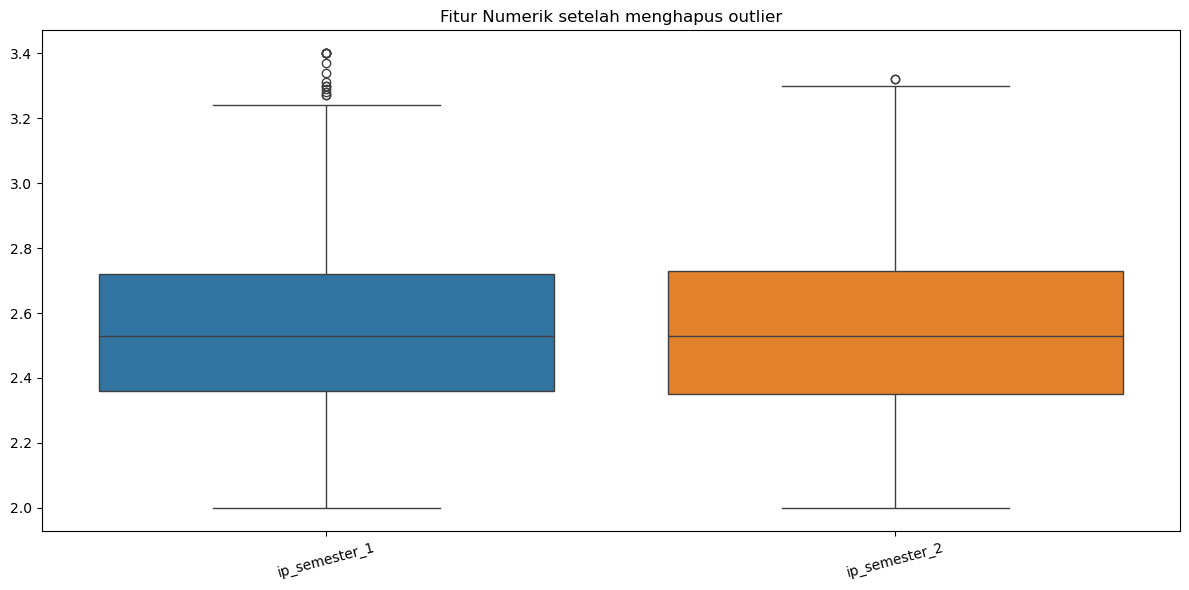

Jumlah baris setelah menghapus outlier: 2812


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1)	Hitung histogram setiap fitur, tampilkan dalam bentuk grafik batang
# ...
for c in dfg.columns:
    if c == "id": 
        continue

    plt.figure(figsize=(6, 4))
    if c in dtObject:
        enc = list(Encoder[c].keys())
        # Untuk data kategori yang sudah di-encode, urutkan berdasarkan index mappingnya
        sns.countplot(data=dfg, x=c)
        plt.title(f"Histogram Batang (Kategori): {c}")
        plt.xticks(rotation= 45 if len(enc) > 3 else 0,ticks=range(len(enc)),labels=enc,ha="right"if len(enc) > 3 else "center")
    else:
        # Untuk data numerik murni
        sns.histplot(data=dfg, x=c, kde=True, color="skyblue")
        plt.title(f"Distribusi dan Histogram: {c}")
    
    plt.xlabel(c)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()
# 2)	Identifikasi outlier dengan boxplot
# ...
plt.figure(figsize=(12, 6))
numeric_fitur = ['ip_semester_1','ip_semester_2']

sns.boxplot(data=dfg[numeric_fitur])
plt.title("Identifikasi Outlier pada Fitur Numerik")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
# 3)	Hapus outlier dari data
# ...
dfg_clean = dfg.copy()

print(f"Jumlah baris sebelum menghapus outlier: {len(dfg_clean)}")

for col in numeric_fitur:
    Q1 = dfg_clean[col].quantile(0.25)
    Q3 = dfg_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter the dataframe to only keep rows within the bounds
    # We also keep rows where the data might be missing (if any remain)
    dfg_clean = dfg_clean[
        (dfg_clean[col] >= lower_bound) & (dfg_clean[col] <= upper_bound) | dfg_clean[col].isna()
    ]
plt.figure(figsize=(12, 6))
sns.boxplot(data=dfg_clean[numeric_fitur])
plt.title("Fitur Numerik setelah menghapus outlier")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"Jumlah baris setelah menghapus outlier: {len(dfg_clean)}")

##Task 6
Agar nantinya kita bisa mendapatkan fitur yang relevan, sebaiknya kita melihat hubungan setiap fitur dengan kelas target.

--- ANALISIS BIVARIATE ---


[Model : Prediksi_Target_Kelulusan]
        ip_semester_1  ip_semester_2
target                              
0            2.425144       2.415650
1            2.619016       2.627552
2            2.450438       2.432154
Linear Regression
Akurasi: 0.5683836589698046
[[  0 119   0]
 [  0 320   0]
 [  0 124   0]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       119
         1.0       0.57      1.00      0.72       320
         2.0       0.00      0.00      0.00       124

    accuracy                           0.57       563
   macro avg       0.19      0.33      0.24       563
weighted avg       0.32      0.57      0.41       563

Polynomial Regression (degree=2)
Akurasi: 0.5683836589698046
[[  0 119   0]
 [  0 320   0]
 [  0 124   0]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       119
         1.0       0.57      1.00      0.72       320
       

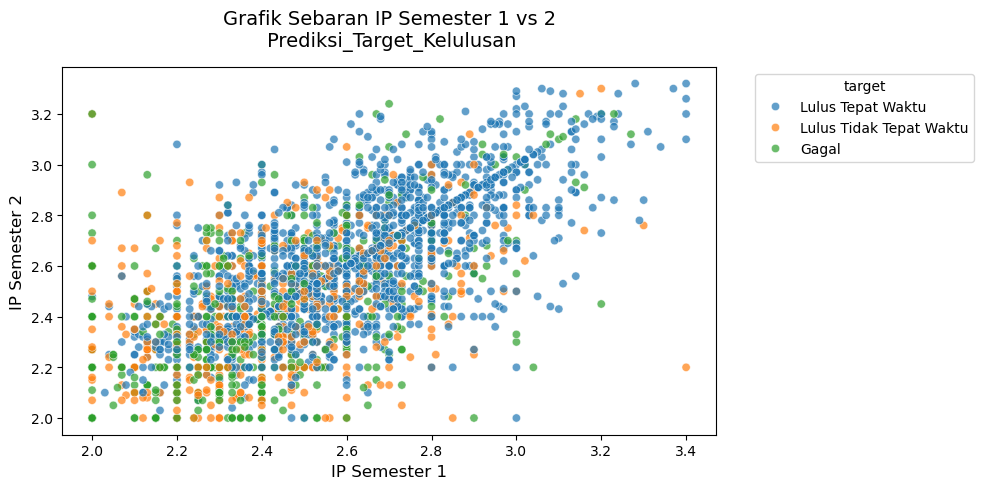


[Model : Prediksi_Penerima_Beasiswa]
        nilai_sma  nilai_ujian_masuk
target                              
0       65.383935          62.498466
1       66.983343          64.298014
2       65.468126          62.550000
Linear Regression
Akurasi: 0.7122557726465364
[[401   0]
 [162   0]]
              precision    recall  f1-score   support

         0.0       0.71      1.00      0.83       401
         1.0       0.00      0.00      0.00       162

    accuracy                           0.71       563
   macro avg       0.36      0.50      0.42       563
weighted avg       0.51      0.71      0.59       563

Polynomial Regression (degree=2)
Akurasi: 0.7122557726465364
[[401   0]
 [162   0]]
              precision    recall  f1-score   support

         0.0       0.71      1.00      0.83       401
         1.0       0.00      0.00      0.00       162

    accuracy                           0.71       563
   macro avg       0.36      0.50      0.42       563
weighted avg       0.51  

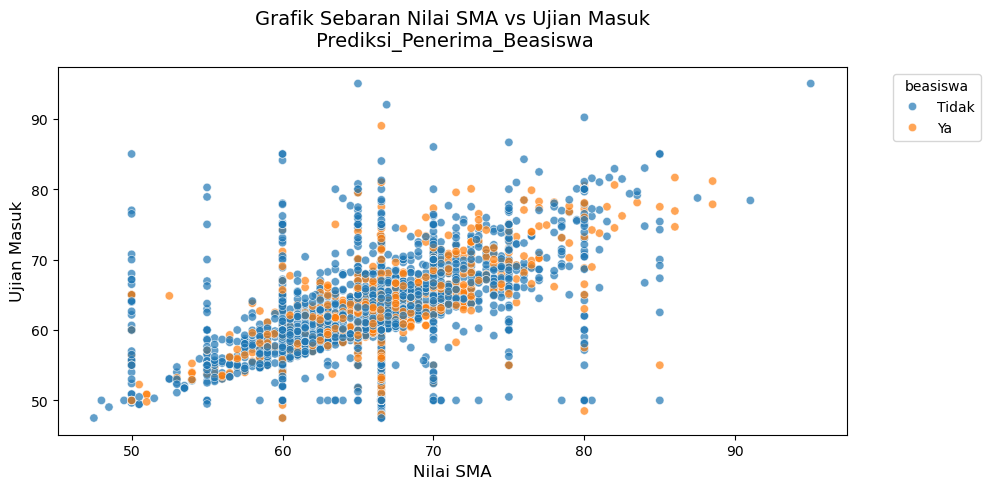

In [6]:
import scipy.stats as stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# 1)	Lakukan analisis bivariate
# ...

target_t = 'target'
target_b = 'beasiswa'
feature_t = ['ip_semester_1', 'ip_semester_2']
feature_b = ['nilai_sma', 'nilai_ujian_masuk']


Xx = [dfg_clean[feature_t],dfg_clean[feature_b]]
yy = [dfg_clean[target_t],dfg_clean[target_b]]

model_names = ["Prediksi_Target_Kelulusan", "Prediksi_Penerima_Beasiswa"]

print("--- ANALISIS BIVARIATE ---\n")
for X, y, name in zip(Xx, yy, model_names):
# Analisis untuk Target Kelulusan
    current_target = target_t if name == model_names[0] else target_b
    current_features = feature_t if name == model_names[0] else feature_b

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 )

    print(f"\n[Model : {name}]")
    print(dfg_clean.groupby(target_t)[current_features].mean())

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)

    # Prediksi dan threshold
    y_pred_lr = lr.predict(X_test_scaled)
    y_pred_lr_class = (y_pred_lr >= 0.5).astype(int)

    print("Linear Regression")
    print("Akurasi:", accuracy_score(y_test, y_pred_lr_class))
    print(confusion_matrix(y_test, y_pred_lr_class))
    print(classification_report(y_test, y_pred_lr_class, zero_division=0))

    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly, y_train)

    y_pred_poly = lr_poly.predict(X_test_poly)
    y_pred_poly_class = (y_pred_poly >= 0.5).astype(int)

    print("Polynomial Regression (degree=2)")
    print("Akurasi:", accuracy_score(y_test, y_pred_poly_class))
    print(confusion_matrix(y_test, y_pred_poly_class))
    print(classification_report(y_test, y_pred_poly_class, zero_division=0))

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)

    print("KNN (k=5)")
    print("Akurasi:", accuracy_score(y_test, y_pred_knn))
    print(confusion_matrix(y_test, y_pred_knn))
    print(classification_report(y_test, y_pred_knn, zero_division=0))

    nb = GaussianNB()
    nb.fit(X_train_scaled, y_train)
    y_pred_nb = nb.predict(X_test_scaled)

    print("Naive Bayes")
    print("Akurasi:", accuracy_score(y_test, y_pred_nb))
    print(confusion_matrix(y_test, y_pred_nb))
    print(classification_report(y_test, y_pred_nb, zero_division=0))

    print("Summary Akurasi:")
    print("Linear Regression     :", f"{accuracy_score(y_test, y_pred_lr_class):.4f}")
    print("Polynomial Regression :", f"{accuracy_score(y_test, y_pred_poly_class):.4f}")
    print("KNN                   :", f"{accuracy_score(y_test, y_pred_knn):4f}")
    print("Naive Bayes           :", f"{accuracy_score(y_test, y_pred_nb):.4f}")


# 2)	Plot kedalam grafik sebaran (scatter)
# ...
    plt.figure(figsize=(10, 5))
    plot_df = X.copy()
    target_map = {0: 'Gagal', 1: 'Lulus Tepat Waktu', 2: 'Lulus Tidak Tepat Waktu'} if name == model_names[0] else {0: 'Tidak',1: 'Ya'}
    plot_df['Target_Label'] = y.map(target_map)
    sns.scatterplot(
        data=plot_df, 
        x='ip_semester_1' if name == model_names[0] else 'nilai_sma', 
        y='ip_semester_2' if name == model_names[0] else 'nilai_ujian_masuk', 
        hue='Target_Label',
        alpha=0.7,
        edgecolor='w'
    )
    plt.title(f"Grafik Sebaran {"IP Semester 1 vs 2" if name == model_names[0] else 'Nilai SMA vs Ujian Masuk'}\n {name}", fontsize=14, pad=15)
    plt.xlabel("IP Semester 1" if name == model_names[0] else 'Nilai SMA', fontsize=12)
    plt.ylabel("IP Semester 2" if name == model_names[0] else 'Ujian Masuk', fontsize=12)
    plt.legend(title=target_t if name == model_names[0] else target_b, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


##Task 7
Oke, sepertinya sudah siap, tapi kok jumlah data per-kelas nya tidak seimbang ya, ada beberapa algoritma yang akan terpengaruh dengan kondisi ini, kita akan gunakan algoritma **$\color{orange}{\text{(Nama Algoritma)}}$** untuk menyelesaikan masalah ini, jadi kita **$\color{orange}{\text{(akan/tidak akan)}}$** melakukan proses augmentasi data karena **$\color{orange}{\text{(Alasan melakukan augmentasi/tidak)}}$**

In [7]:
# 1)	Augmentasi data untuk balancing kelas (Optional)
# ...
from sklearn.ensemble import RandomForestClassifier
# Parameter 'balanced' otomatis mengatur bobot berbanding terbalik dengan frekuensi kelas
def augment(X_train_scaled,
            y_train,
            n_estimator:int,
            max_depth:int,
            min_samples_split:int,
            min_samples_leaf:int): 
    model = RandomForestClassifier(
        n_estimators=n_estimator,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42)
    return model.fit(X_train_scaled, y_train)

Selanjutnya datanya perlu kita bagi dengan ratio **$\color{orange}{\text{(.?.)}}$** : **$\color{orange}{\text{(.?.)}}$**
Dimana **$\color{orange}{\text{(.?.)}}$** adalah data training
Dan **$\color{orange}{\text{(.?.)}}$** adalah data testing


In [8]:
# 1)	Lakukan pembagian data training dan testing
# ...
def splitnScale (X,y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test,X_train_scaled,X_test_scaled

##Task 8
Sekarang kita mulai training nya

Memulai Training : Prediksi_Target_Kelulusan

Akurasi Testing: 0.6660746003552398

Classification Report:
              precision    recall  f1-score   support

         0.0       0.60      0.39      0.47       111
         1.0       0.70      0.94      0.80       338
         2.0       0.38      0.11      0.18       114

    accuracy                           0.67       563
   macro avg       0.56      0.48      0.48       563
weighted avg       0.61      0.67      0.61       563


Akurasi Cross-Validation (5 Lipatan): [0.6625222  0.6660746  0.66903915 0.67081851 0.71530249]
Rata-rata Akurasi CV: 0.6768

Akurasi pada Data Latih (Training): 0.7021
Akurasi pada Data Uji (Testing)  : 0.6661
-> Status: Model dalam batas wajar (Good Fit)


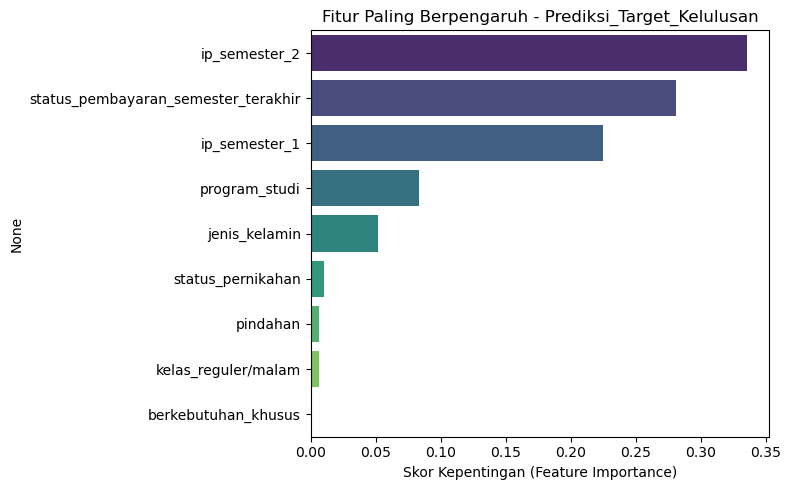

Memulai Training : Prediksi_Penerima_Beasiswa

Akurasi Testing: 0.7140319715808171

Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      1.00      0.83       403
         1.0       0.33      0.01      0.01       160

    accuracy                           0.71       563
   macro avg       0.52      0.50      0.42       563
weighted avg       0.61      0.71      0.60       563


Akurasi Cross-Validation (5 Lipatan): [0.71047957 0.71225577 0.70462633 0.74911032 0.6975089 ]
Rata-rata Akurasi CV: 0.7148

Akurasi pada Data Latih (Training): 0.7243
Akurasi pada Data Uji (Testing)  : 0.7140
-> Status: Model dalam batas wajar (Good Fit)


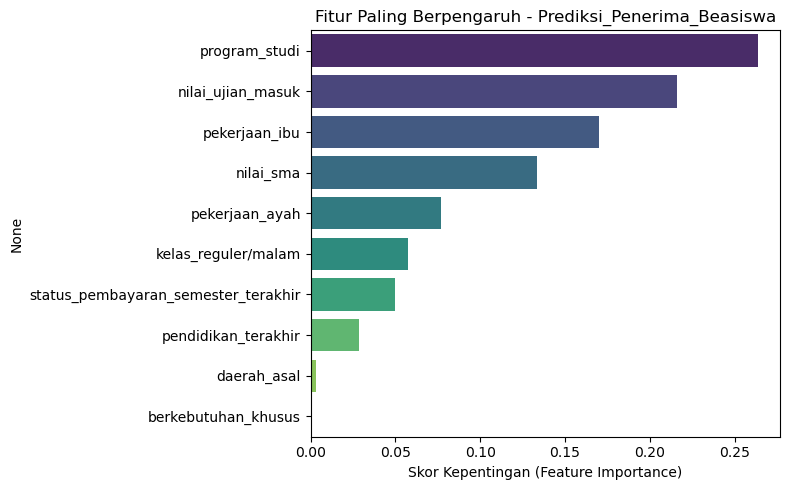

In [9]:
# 1)	Lakukan proses training dengan algoritma yang telah dipilih
# ...
feature_t = ['ip_semester_1', 'ip_semester_2', 'program_studi', 'kelas_reguler/malam', 
             'berkebutuhan_khusus', 'jenis_kelamin', 'status_pernikahan', 'pindahan',
             'status_pembayaran_semester_terakhir']
feature_b = ['nilai_sma', 'nilai_ujian_masuk', 'program_studi', 'kelas_reguler/malam', 
             'pendidikan_terakhir', 'daerah_asal', 'pekerjaan_ibu', 'pekerjaan_ayah', 
             'berkebutuhan_khusus', 'status_pembayaran_semester_terakhir']

Xx = [dfg_clean[feature_t],dfg_clean[feature_b]]
yy = [dfg_clean[target_t],dfg_clean[target_b]]
X_tr,X_te = {},{}
y_Tr,y_te = {},{}

for X, y, name in zip(Xx, yy, model_names):
    print(f"Memulai Training : {name}\n")
    X_train, X_test, y_train, y_test,X_train_scaled,X_test_scaled = splitnScale(X,y)
    
    X_tr[name],X_te[name] = X_train,X_test
    y_Tr[name],y_te[name] = y_train,y_test

    model = augment(X_train_scaled,y_train,
                    n_estimator=100,
                    max_depth=5,
                    min_samples_leaf=5,
                    min_samples_split=10)
    y_pred = model.predict(X_test_scaled)
    print("Akurasi Testing:", accuracy_score(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# 2)	Lakukan evaluasi model dengan K-fold
# ...
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    X_scaled_all = scaler.fit_transform(X) # Scale ulang full data khusus untuk CV
    cv_scores = cross_val_score(model, X_scaled_all, y, cv=kf,scoring='accuracy')
    print(f"\nAkurasi Cross-Validation (5 Lipatan): {cv_scores}")
    print(f"Rata-rata Akurasi CV: {cv_scores.mean():.4f}")

    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    print(f"\nAkurasi pada Data Latih (Training): {train_acc:.4f}")
    print(f"Akurasi pada Data Uji (Testing)  : {test_acc:.4f}")

    if train_acc > test_acc + 0.1:
        print("-> Status: Model kemungkinan OVERFITTING (Terlalu menghafal data latih)")
    elif test_acc > train_acc + 0.1:
        print("-> Status: Model kemungkinan UNDERFITTING (Gagal menemukan pola)")
    else:
        print("-> Status: Model dalam batas wajar (Good Fit)")

    plt.figure(figsize=(8, 5))
    importances = model.feature_importances_
    feat_names = X.columns
    indices = importances.argsort()[::-1] # Urutkan dari yang paling penting
    
    sns.barplot(x=importances[indices], y=feat_names[indices],hue=feat_names[indices], palette="viridis")
    plt.title(f"Fitur Paling Berpengaruh - {name}")
    plt.xlabel("Skor Kepentingan (Feature Importance)")
    plt.tight_layout()
    plt.show()


#Task 9
Training sudah selesai dan model sudah diketahui, kita uji hasilnya dengan data testing untuk melihat kemungkinan overfitting dan underfitting, sekaligus menghitung kualitas model dengan matrik pengukuran

--- EVALUASI OVERFITTING / UNDERFITTING ---
Akurasi Data Latih (Train) : 0.7020898176967542
Akurasi Data Uji (Test)    : 0.6660746003552398
-> Model GOOD FIT: Jarak akurasi antara train dan test wajar (model dapat digeneralisasi dengan baik).

--- CLASSIFICATION REPORT (DATA UJI) ---
              precision    recall  f1-score   support

         0.0       0.60      0.39      0.47       111
         1.0       0.70      0.94      0.80       338
         2.0       0.38      0.11      0.18       114

    accuracy                           0.67       563
   macro avg       0.56      0.48      0.48       563
weighted avg       0.61      0.67      0.61       563


--- CONFUSION MATRIX ---


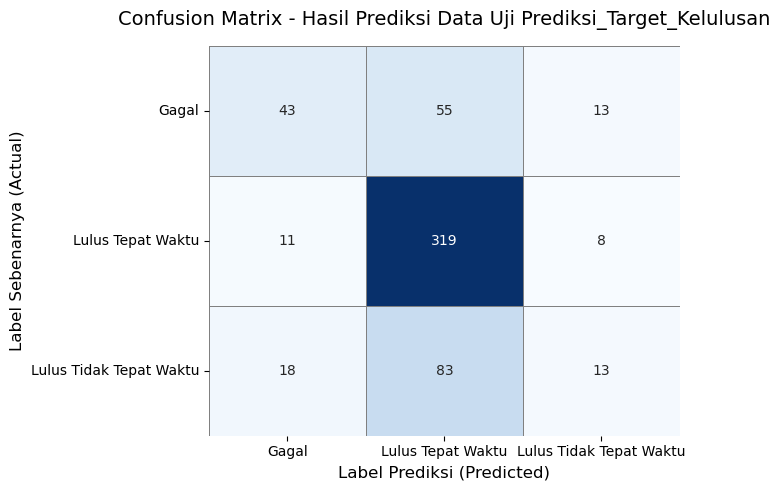

--- EVALUASI OVERFITTING / UNDERFITTING ---
Akurasi Data Latih (Train) : 0.7243219208537127
Akurasi Data Uji (Test)    : 0.7140319715808171
-> Model GOOD FIT: Jarak akurasi antara train dan test wajar (model dapat digeneralisasi dengan baik).

--- CLASSIFICATION REPORT (DATA UJI) ---
              precision    recall  f1-score   support

         0.0       0.72      1.00      0.83       403
         1.0       0.33      0.01      0.01       160

    accuracy                           0.71       563
   macro avg       0.52      0.50      0.42       563
weighted avg       0.61      0.71      0.60       563


--- CONFUSION MATRIX ---


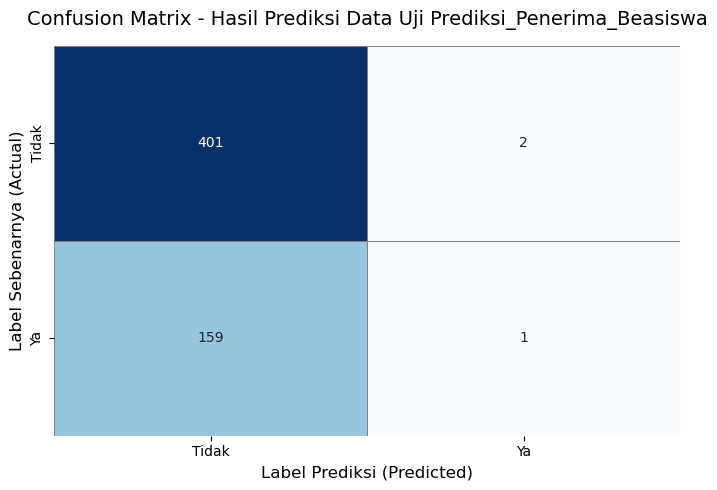

In [10]:
# 1)	Evaluasi dengan data testing
# ...
for name in model_names:
    X_train,X_test = X_tr[name],X_te[name]
    y_train,y_test = y_Tr[name],y_te[name]
# ==========================================
# 1. PREDIKSI PADA DATA TRAIN DAN TEST
# ==========================================
# (Asumsi kita menggunakan 'model_robust' dan data split dari langkah sebelumnya)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model = augment(X_train_scaled,y_train,
                        n_estimator=100,
                        max_depth=5,
                        min_samples_leaf=5,
                        min_samples_split=10)
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)


    # ==========================================
    # 2. CEK OVERFITTING & UNDERFITTING
    # ==========================================
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    print("--- EVALUASI OVERFITTING / UNDERFITTING ---")
    print(f"Akurasi Data Latih (Train) :", acc_train)
    print(f"Akurasi Data Uji (Test)    :", acc_test)

    # Analisis sederhana otomatis
    selisih = acc_train - acc_test
    if selisih > 0.10:
        print("-> Indikasi OVERFITTING: Model terlalu menghafal data latih dan gagal di data uji.")
    elif acc_train < 0.60 and acc_test < 0.60:
        print("-> Indikasi UNDERFITTING: Model belum cukup belajar, akurasi sangat rendah di kedua data.")
    else:
        print("-> Model GOOD FIT: Jarak akurasi antara train dan test wajar (model dapat digeneralisasi dengan baik).")


    # ==========================================
    # 3. METRIK PENGUKURAN (CLASSIFICATION REPORT)
    # ==========================================
    print("\n--- CLASSIFICATION REPORT (DATA UJI) ---")
    # Menampilkan metrik Precision, Recall, dan F1-Score
    print(classification_report(y_test, y_pred_test))
    # 2)	Hitung dengan matrik pengukuran
    # ...
    print("\n--- CONFUSION MATRIX ---")
    # Menghitung confusion matrix
    cm = confusion_matrix(y_test, y_pred_test)

    # Plotting confusion matrix menggunakan seaborn heatmap
    plt.figure(figsize=(7, 5))
    class_labels = ['Gagal','Lulus Tepat Waktu','Lulus Tidak Tepat Waktu'] if name == model_names[0] else ['Tidak','Ya']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=False, linewidths=0.5, linecolor='gray',
                xticklabels=class_labels, yticklabels=class_labels)

    plt.title(f"Confusion Matrix - Hasil Prediksi Data Uji {name}", fontsize=14, pad=15)
    plt.xlabel("Label Prediksi (Predicted)", fontsize=12)
    plt.ylabel("Label Sebenarnya (Actual)", fontsize=12)
    plt.tight_layout()
    plt.show()

##Task 10
Berdasarkan hasil evaluasi, kita bisa menyimpulkan bahwa

**$\color{orange}{\text{(Lakukan analisis hasil )}}$**